In [42]:
# simple imports fot data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

/home/david/repos/KK1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [43]:
# loading the dataset into a pandas dataframe and displaying the first few rows to understand its structure and contents
df = pd.read_csv("data/asteroids_data.csv")
df.head()

,id,neo_id,name,short_name,designation,nasa_url,magnitude,potentially_hazardous,close_approach_data,sentry,...,perihelion_argument,aphelion_distance,perihelion_time,mean_anomaly,mean_motion,equinox,orbit_class_type,orbit_class_desc,orbit_class_range,sentry_data
0,2001620,2001620,1620 Geographos (1951 RA),Geographos,1620,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,15.26,True,"[{'close_approach_date': '1901-08-23', 'close_...",False,...,277.018390,1.663750,2.461208e+06,212.920449,0.708833,J2000,APO,Near-Earth asteroid orbits which cross the Ear...,a (semi-major axis) > 1.0 AU; q (perihelion) <...,NaN
1,2001863,2001863,1863 Antinous (1948 EA),Antinous,1863,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,15.35,False,"[{'close_approach_date': '1907-10-11', 'close_...",False,...,269.074546,3.630348,2.461243e+06,289.564484,0.290073,J2000,APO,Near-Earth asteroid orbits which cross the Ear...,a (semi-major axis) > 1.0 AU; q (perihelion) <...,NaN
2,2001915,2001915,1915 Quetzalcoatl (1953 EA),Quetzalcoatl,1915,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,18.38,False,"[{'close_approach_date': '1906-03-06', 'close_...",False,...,347.755255,3.995972,2.460911e+06,21.616448,0.242780,J2000,AMO,Near-Earth asteroid orbits similar to that of ...,1.017 AU < q (perihelion) < 1.3 AU,NaN
3,2001917,2001917,1917 Cuyo (1968 AA),Cuyo,1917,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,14.38,False,"[{'close_approach_date': '1926-09-28', 'close_...",False,...,194.552572,3.235478,2.460489e+06,160.089498,0.312848,J2000,AMO,Near-Earth asteroid orbits similar to that of ...,1.017 AU < q (perihelion) < 1.3 AU,NaN
4,2002063,2002063,2063 Bacchus (1977 HB),Bacchus,2063,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,17.21,False,"[{'close_approach_date': '1903-03-06', 'close_...",False,...,55.350732,1.454683,2.461143e+06,234.787011,0.880596,J2000,APO,Near-Earth asteroid orbits which cross the Ear...,a (semi-major axis) > 1.0 AU; q (perihelion) <...,NaN


In [44]:
# playing around with the dataset to understand its structure and contents better, checking for missing values, data types. 
# this is just more for fun and playing around with what i can do with the dataset, not really for any specific purpose.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        2000 non-null   int64  
 1   neo_id                    2000 non-null   int64  
 2   name                      2000 non-null   str    
 3   short_name                167 non-null    str    
 4   designation               2000 non-null   int64  
 5   nasa_url                  2000 non-null   str    
 6   magnitude                 2000 non-null   float64
 7   potentially_hazardous     2000 non-null   bool   
 8   close_approach_data       2000 non-null   str    
 9   sentry                    2000 non-null   bool   
 10  api_url                   2000 non-null   str    
 11  diameter_min_m            2000 non-null   float64
 12  diameter_max_m            2000 non-null   float64
 13  orbit_id                  2000 non-null   int64  
 14  orbit_determination

In [45]:
# same here 
df.describe()

,id,neo_id,designation,magnitude,diameter_min_m,diameter_max_m,orbit_id,data_arc_days,observations_used,orbit_uncertainty,...,semi_major_axis,inclination,ascending_node_longitude,orbital_period,perihelion_distance,perihelion_argument,aphelion_distance,perihelion_time,mean_anomaly,mean_motion
count,2.000000e+03,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000
mean,2.238991e+06,2.238991e+06,238991.254000,18.276285,801.395362,1791.974506,153.693000,10328.96750,953.600500,0.025500,...,1.726671,17.980331,177.152353,859.638786,0.883154,183.632978,2.570188,2.460987e+06,176.132468,0.533410
std,1.415611e+05,1.415611e+05,141561.139095,1.606527,1202.526102,2688.930109,147.735936,5267.36773,1338.062669,0.166924,...,0.546075,13.437211,101.018250,402.893662,0.294635,102.880776,0.994120,3.058995e+02,102.271587,0.292171
min,2.000433e+06,2.000433e+06,433.000000,9.170000,36.690614,82.042706,13.000000,364.00000,34.000000,0.000000,...,0.615942,0.147850,0.104075,176.566270,0.081738,0.088952,0.803780,2.455439e+06,0.018100,0.111717
25%,2.140322e+06,2.140322e+06,140321.750000,17.237500,360.209346,805.452583,66.000000,7601.50000,264.000000,0.000000,...,1.315229,7.658565,94.266035,550.934867,0.663091,94.177618,1.773754,2.460810e+06,88.677408,0.316642
50%,2.242201e+06,2.242201e+06,242201.000000,18.330000,573.528464,1282.448632,105.500000,8813.00000,501.500000,0.000000,...,1.668896,14.583894,174.170701,787.484783,0.926804,189.966425,2.386299,2.460987e+06,172.217382,0.457152
75%,2.368976e+06,2.368976e+06,368976.000000,19.340000,948.540417,2121.000852,188.000000,11791.75000,1097.000000,0.000000,...,2.131850,24.873738,261.617352,1136.929090,1.137928,271.921991,3.249859,2.461167e+06,263.951158,0.653435
max,2.448721e+06,2.448721e+06,448721.000000,24.300000,38954.261613,87104.376979,1508.000000,46582.00000,14430.000000,2.000000,...,4.269628,154.349019,359.937878,3222.429795,1.299656,359.864922,7.289483,2.461994e+06,359.622053,2.038895


In [46]:
# same here but i gott something out of it, there are some missing values in the dataset, which i will have to deal with later on when i start doing some data cleaning and preprocessing.
df.isnull().sum()

id                             0
neo_id                         0
name                           0
short_name                  1833
designation                    0
nasa_url                       0
magnitude                      0
potentially_hazardous          0
close_approach_data            0
sentry                         0
api_url                        0
diameter_min_m                 0
diameter_max_m                 0
orbit_id                       0
orbit_determination_date       0
first_observation_date         0
last_observation_date          0
data_arc_days                  0
observations_used              0
orbit_uncertainty              0
min_orbit_intersection         0
jupiter_tisserand              0
epoch                          0
eccentricity                   0
semi_major_axis                0
inclination                    0
ascending_node_longitude       0
orbital_period                 0
perihelion_distance            0
perihelion_argument            0
aphelion_d

In [ ]:
# here i am dropping rows in the dataset that contain missing values.
df = df.drop_duplicates()
df

,id,neo_id,name,short_name,designation,nasa_url,magnitude,potentially_hazardous,close_approach_data,sentry,...,perihelion_argument,aphelion_distance,perihelion_time,mean_anomaly,mean_motion,equinox,orbit_class_type,orbit_class_desc,orbit_class_range,sentry_data
419,2101955,2101955,101955 Bennu (1999 RQ36),Bennu,101955,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,20.21,True,"[{'close_approach_date': '1900-06-15', 'close_...",True,...,66.223061,1.355888,2.455439e+06,101.703952,0.824461,J2000,APO,Near-Earth asteroid orbits which cross the Ear...,a (semi-major axis) > 1.0 AU; q (perihelion) <...,http://api.nasa.gov/neo/rest/v1/neo/sentry/210...


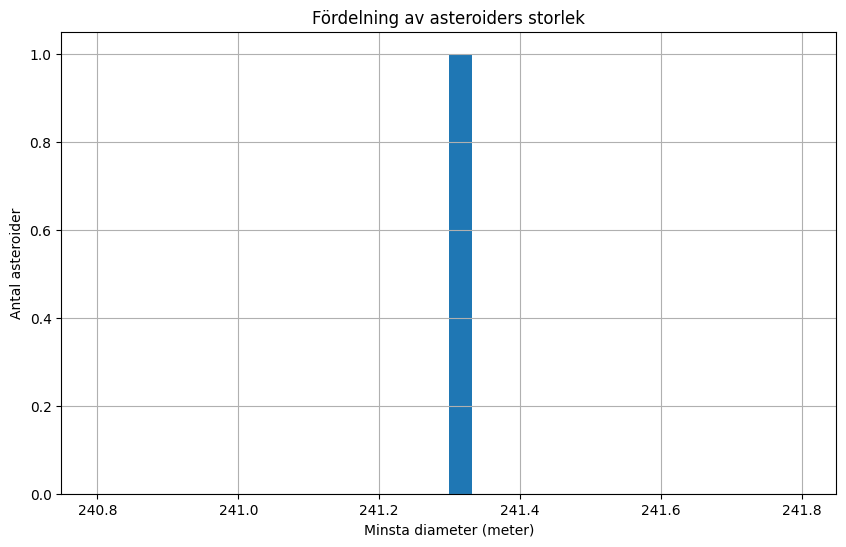

In [48]:
import matplotlib.pyplot as plt

# making my canvas for the histogram of the distrubution of the size of the asteroids and how many asteroids there are of each size, this is just for fun and to get a better understanding of the dataset.
plt.figure(figsize=(10,6))

# plotting the histogram of the distribution of the size of the asteroids, using the column "diameter_min_m" which is the minimum diameter of the asteroid in meters.
plt.hist(df["diameter_min_m"], bins=30)

# adding title and labels to the plot to make it more informative and easier to understand.
plt.title("Fördelning av asteroiders storlek")
plt.xlabel("Minsta diameter (meter)")
plt.ylabel("Antal asteroider")

plt.grid()

# showing the plot to visualize the distribution of the size of the asteroids in the dataset.
plt.show()

# Potentiellt farliga asteroider 

Här är en graf på dem som är potentiellt farliga för jorden men inte uppdelade efter något utan endast antal farliga och icke farliga.

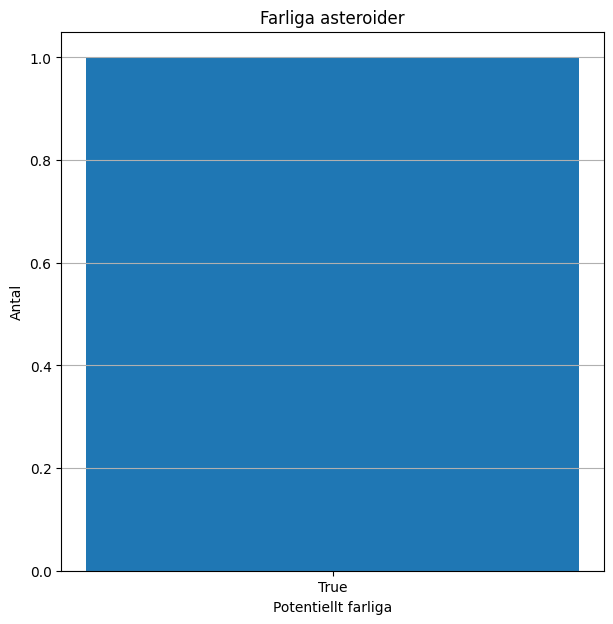

In [49]:
# now i want to see how many of the asteroids in the dataset are potentially hazardous.
counts = df["potentially_hazardous"].value_counts()

# making a bar plot to visualize the counts of potentially hazardous asteroids in the dataset.
plt.figure(figsize=(7,7))

# plotting the bar of the counts of potentially hazardous asteroids using the index of the counts as the x-axis and the values of the counts as the y-axis.
plt.bar(
    counts.index.astype(str),
    counts.values
)

plt.title("Farliga asteroider")
plt.xlabel("Potentiellt farliga")
plt.ylabel("Antal")

plt.grid(axis='y')

plt.show()

# Amor / Apollo / Aten
dessa är det olika omlopps banorna och som man ser är dem som krettsar i apollo flest som är i risk för att vara farliga. <br>
Dem som är i Amor banan är minst risk på grund av att amor inte korsar jordens kretsbana runt solen så som apollo som både korsar och är nära parallel till jorden. <br>
Atens omloppsbana korsar jordens omloppsbana och går inte parallelt så som apollo. 

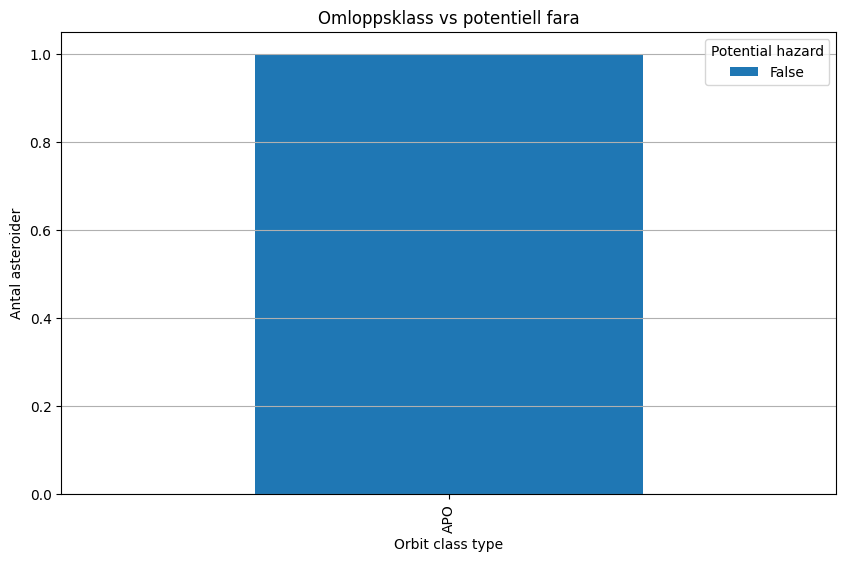

In [50]:
import pandas as pd

# now i want to see if there is any correlation between the orbit class type of the asteroids and whether they are potentially hazardous or not.
pd.crosstab(df['orbit_class_type'], df['potentially_hazardous']).plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Omloppsklass vs potentiell fara')
plt.xlabel('Orbit class type')
plt.ylabel('Antal asteroider')
plt.legend(['False', 'True'], title='Potential hazard')
# adding grid to the y-axis to make it easier to read the values from the plot.
plt.grid(axis='y')
plt.show()

/tmp/ipykernel_52371/3761601219.py:6: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(x, y, 1)


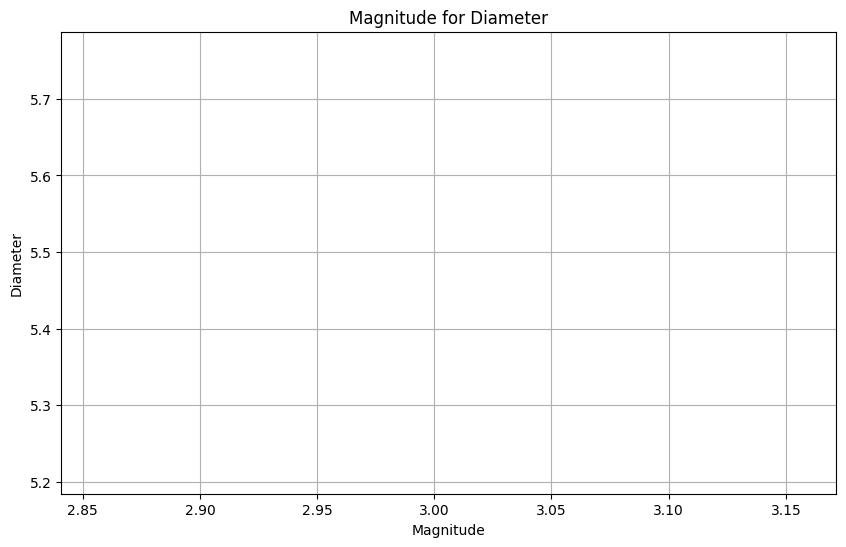

In [51]:
#Diameter and magnitude compared
x = np.log(df['magnitude'])
y = np.log(df['diameter_min_m'])

# Create trend line
m, b = np.polyfit(x, y, 1)

# figure
plt.figure(figsize=(10, 6))

# regresionline
plt.plot(x, m*x + b, color='red', linewidth=3)

# labels
plt.xlabel('Magnitude')
plt.ylabel('Diameter')
plt.title('Magnitude for Diameter')

plt.grid(True)

plt.show()

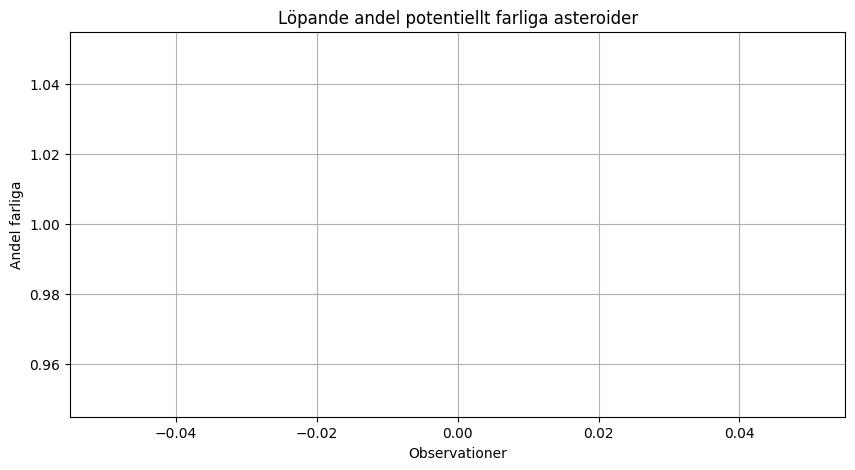

In [52]:
# now i want to see how the proportion of potentially hazardous asteroids changes over time
y = df['potentially_hazardous'].astype(int).values
cum_mean = np.cumsum(y) / np.arange(1, len(y) + 1)

plt.figure(figsize=(10,5))
plt.plot(cum_mean)

# adding title and labels to the plot to make it more informative and easier to understand.
plt.title('Löpande andel potentiellt farliga asteroider')
plt.xlabel('Observationer')
plt.ylabel('Andel farliga')

plt.grid()
plt.show()

# diameter för farliga asteroider & antal 

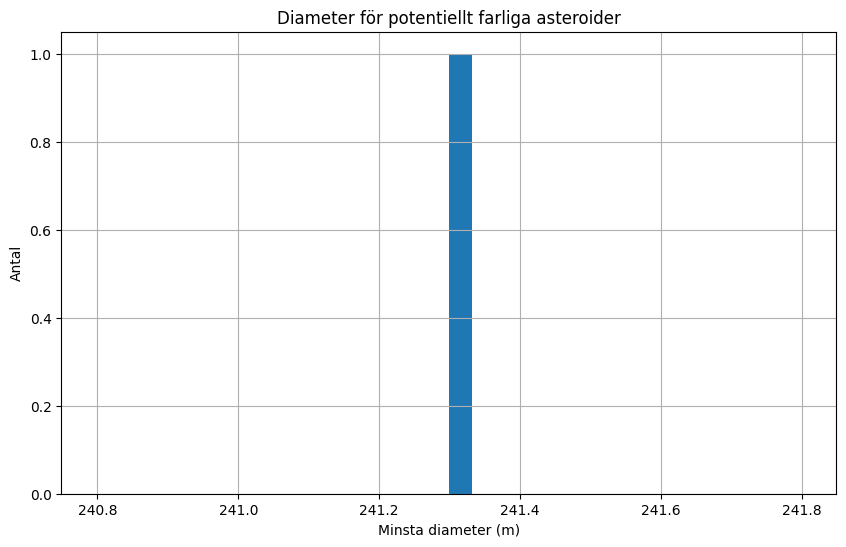

In [53]:
# this is kind of the same as the first histogram but now i want to see the distribution of the size of the potentially hazardous asteroids, to see if there is any difference in size distribution for the potentially hazardous
hazardous_counts = df[df['potentially_hazardous'] == True]

plt.figure(figsize=(10,6))
plt.hist(hazardous_counts['diameter_min_m'], bins=30)
plt.title('Diameter för potentiellt farliga asteroider')
plt.xlabel('Minsta diameter (m)')
plt.ylabel('Antal')
plt.grid()
plt.show()

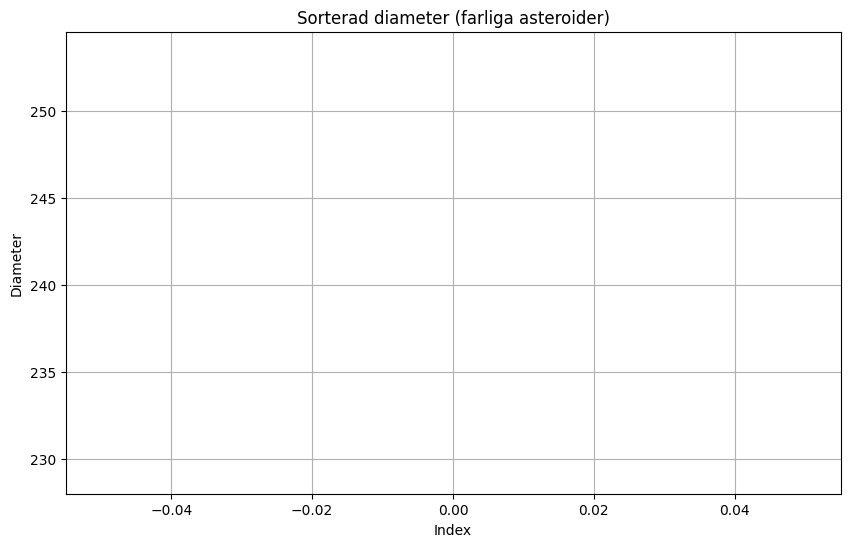

In [54]:
# trying to plot the sorted diameter of the potentially hazardous asteroids to see if there is any pattern in the size distribution of the potentially hazardous asteroids.
sorted_data = hazardous_counts['diameter_min_m'].sort_values().reset_index(drop=True)

plt.figure(figsize=(10,6))
plt.plot(sorted_data)

plt.title('Sorterad diameter (farliga asteroider)')
plt.xlabel('Index')
plt.ylabel('Diameter')

plt.grid()
plt.show()

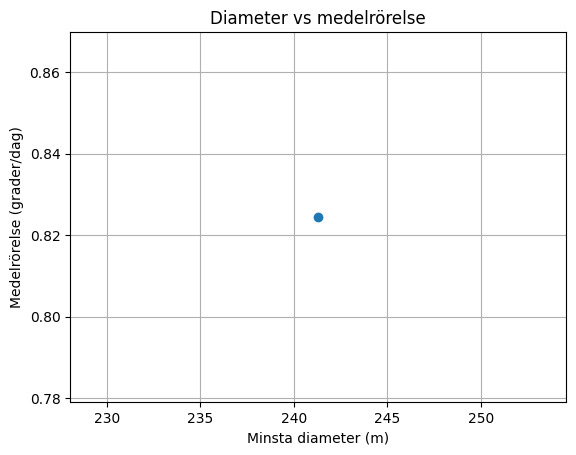

In [55]:
# now i want to see if there is any correlation between the diameter of the asteroids and their mean motion, to see if there is any pattern in the relationship between the size of the asteroids and their mean motion.
plt.scatter(df['diameter_min_m'], df['mean_motion'])

plt.title('Diameter vs medelrörelse')
plt.xlabel('Minsta diameter (m)')
plt.ylabel('Medelrörelse (grader/dag)')
plt.grid()
plt.show()

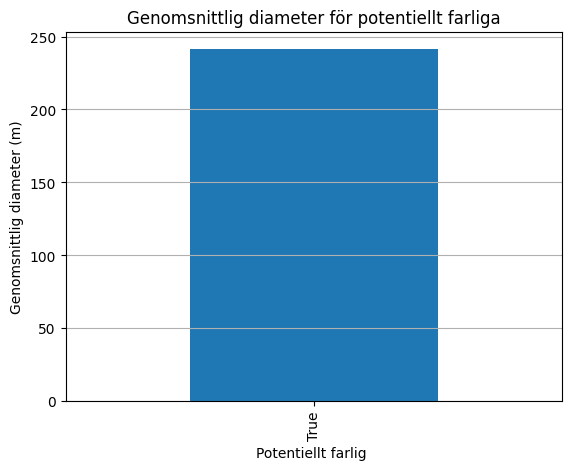

In [56]:
# now i made it into bar plots instead. 
df.groupby('potentially_hazardous')['diameter_min_m'].mean().plot(kind='bar')

plt.title('Genomsnittlig diameter för potentiellt farliga')
plt.xlabel('Potentiellt farlig ')
plt.ylabel('Genomsnittlig diameter (m)')
plt.grid(axis='y')
plt.show()